# FinPlan — Interactive Walkthrough

**Goal-based investment planning, from a natural-language goal to a numerically-exact plan.**

This notebook drives the **same deterministic engine** that powers the FinPlan app and API. It runs
**with no API key** — every figure below is computed by pure, unit-tested Python functions in the
[`finplan`](../finplan) package, not by an LLM.

> **The one design principle:** *the LLM never does arithmetic, unit conversion, or number formatting.*
> Every rupee figure is computed, parsed, and formatted in deterministic Python; the model only
> orchestrates these tools, interprets the results, and quotes the pre-formatted strings. This notebook
> shows the deterministic half you can trust — step by step — and then, optionally, the LLM layer on top.

**How to run:** open in Jupyter / VS Code / Colab and *Run All*. Charts are rendered with
**matplotlib** (static images) so they show up on GitHub without re-running. The final section talks to
the LLM agent and is **skipped automatically** if no provider key is set.

---

## 0. Setup

Put the repo root on the import path (so `import finplan` works from the `notebooks/` folder), then set a
clean chart style and a small helper that formats rupee values compactly for axis labels.

In [1]:
import sys, pathlib

# Walk up from the working directory until we find the folder containing `finplan/`.
_cwd = pathlib.Path.cwd()
_root = next((d for d in [_cwd, *_cwd.parents] if (d / "finplan").is_dir()), _cwd)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("repo root:", _root)

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7, 4.2),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Compact, ASCII-safe rupee labels for chart axes/annotations (charts render as
# images, so we avoid the ₹ glyph here; printed text below uses format_inr / ₹).
def inr_compact(x, pos=None):
    x = float(x)
    if abs(x) >= 1e7:
        return f"Rs {x / 1e7:.2f} Cr"
    if abs(x) >= 1e5:
        return f"Rs {x / 1e5:.1f} L"
    return f"Rs {x:,.0f}"

EQUITY, DEBT, GOLD = "#2a9d8f", "#264653", "#e9c46a"
ACCENT = "#e76f51"

repo root: C:\Users\prana\Documents\Projects\Financial AI Agent


Matplotlib is building the font cache; this may take a moment.


## 1. The scenario

We'll plan one goal end to end. In the app the user types this in plain English
(*"I have ₹2 lakh now, can add ₹15k/month for 12 years, want ₹50 lakh, moderate risk"*) and the LLM
extracts the five inputs. Here we set them directly. Money is formatted by
[`finplan.parsing.format_inr`](../finplan/parsing.py) — note the **Indian digit grouping** (`₹48,51,170`,
not `₹4,851,170`).

In [2]:
from finplan.parsing import format_inr

inputs = {
    "initial": 200_000,      # lump sum today
    "monthly": 15_000,       # monthly SIP
    "years": 12,             # horizon
    "goal": 5_000_000,       # target corpus (₹50 lakh)
    "risk_tolerance": "medium",
}

print("Initial lump sum :", format_inr(inputs["initial"]))
print("Monthly SIP      :", format_inr(inputs["monthly"]))
print("Horizon          :", inputs["years"], "years")
print("Goal             :", format_inr(inputs["goal"]))
print("Risk tolerance   :", inputs["risk_tolerance"])

Initial lump sum : ₹2,00,000
Monthly SIP      : ₹15,000
Horizon          : 12 years
Goal             : ₹50,00,000
Risk tolerance   : medium


## 2. Risk profile — `min(capacity, willingness)`

[`assess_risk_profile`](../finplan/tools/risk.py) combines **capacity** (objective, from the horizon —
a short horizon can't ride out a crash) with **willingness** (what the user stated) and takes the
**lower of the two**, so we never advise more risk than *both* support. The function returns a
plain-English rationale, so the decision is fully explainable.

In [3]:
from finplan.tools.risk import assess_risk_profile

prof = assess_risk_profile(inputs["years"], inputs["risk_tolerance"])
profile = prof["profile"]
print("Profile   :", profile)
print("Capacity  :", prof["capacity"], "(from horizon)")
print("Willingness:", prof["willingness"], "(stated)")
print("Rationale :", prof["rationale"])

Profile   : moderate
Capacity  : aggressive (from horizon)
Willingness: moderate (stated)
Rationale : Horizon of 12y implies aggressive capacity; stated tolerance is moderate. Taking the lower of the two -> moderate.


## 3. Asset allocation — a horizon glide-path

[`recommend_allocation`](../finplan/tools/risk.py) starts from a base equity/debt/gold split for the
profile, then applies an **equity ceiling that rises with the horizon** (30/50/70/100% at
<3/<5/<7/≥7 years); any excess equity moves to debt so the weights still sum to 100.

In [4]:
from finplan.tools.risk import recommend_allocation

alloc = recommend_allocation(profile, inputs["years"])
allocation = alloc["allocation"]
print("Allocation:", allocation)
print("Note      :", alloc["note"])

Allocation: {'equity': 60, 'debt': 30, 'gold': 10}
Note      : Standard allocation for this profile.


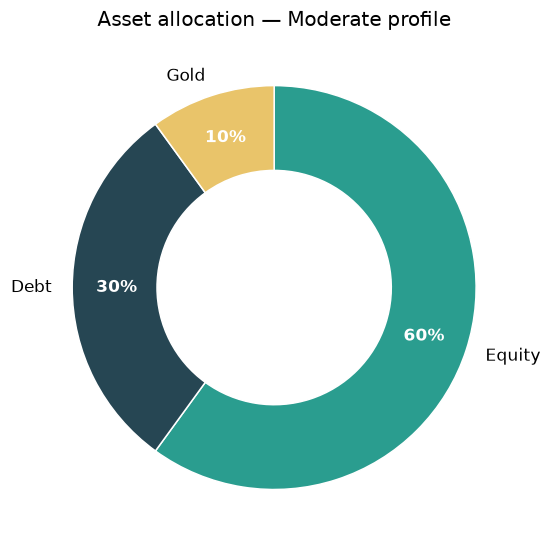

In [5]:
labels = list(allocation.keys())
sizes = list(allocation.values())
colors = {"equity": EQUITY, "debt": DEBT, "gold": GOLD}

fig, ax = plt.subplots(figsize=(5.2, 5.2))
_, _, autos = ax.pie(
    sizes,
    labels=[l.title() for l in labels],
    colors=[colors[l] for l in labels],
    autopct=lambda p: f"{p:.0f}%",
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white"),
    pctdistance=0.78, textprops=dict(fontsize=11),
)
for a in autos:
    a.set_color("white"); a.set_fontweight("bold")
ax.set_title(f"Asset allocation — {profile.title()} profile")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 4. Real market data (with graceful fallback)

[`_class_stats`](../finplan/planner.py) fetches real return/risk per asset class from **yfinance** (NSE
proxies) and is **LRU-cached with a fallback to assumed numbers** if the network is unavailable — so this
cell never breaks offline. Using the *same* `_class_stats` the composite planner uses means the one-call
plan in §10 will reproduce these exact numbers.

In [6]:
from finplan.planner import _class_stats

market_data = {}
for cls in ("equity", "debt", "gold"):
    cagr, vol, source = _class_stats(cls)
    market_data[cls] = {"cagr": cagr, "volatility": vol, "source": source}

for cls, s in market_data.items():
    print(f"{cls:7s} {s['cagr'] * 100:5.2f}% CAGR   {s['volatility'] * 100:5.2f}% vol   [{s['source']}]")

equity  11.08% CAGR   16.23% vol   [^NSEI (10.0y live)]
debt     7.29% CAGR   12.96% vol   [LTGILTBEES.NS (8.16y live)]
gold    15.32% CAGR   15.92% vol   [GOLDBEES.NS (10.0y live)]


## 5. Blend into a portfolio return & volatility

[`blended_portfolio_stats`](../finplan/tools/risk.py) takes the allocation-weighted average of the class
CAGRs for the expected return. Volatility is *also* a weighted average — but that assumes **perfect
correlation** between classes (it ignores diversification), so it's deliberately named a **conservative
upper bound** rather than overstating precision.

In [7]:
from finplan.tools.risk import blended_portfolio_stats

blended = blended_portfolio_stats(allocation, market_data)
er = blended["expected_return"]
vol = blended["volatility_upper_bound"]
print(f"Expected return          : {er * 100:.2f}%")
print(f"Volatility (upper bound) : {vol * 100:.2f}%")

Expected return          : 10.37%
Volatility (upper bound) : 15.22%


## 6. Projection — exact future value

[`project_growth`](../finplan/tools/projection.py) computes the future value of the lump sum (compounded)
plus the SIP (an ordinary annuity), using a **monthly rate of `(1+annual)^(1/12) − 1`** — the 12th root,
not `annual/12`, so twelve months compound back to *exactly* the annual return.

In [8]:
from finplan.tools.projection import project_growth

projection = project_growth(inputs["initial"], inputs["monthly"], inputs["years"], er)
print("Projected corpus:", format_inr(projection["future_value"]))
print("Total invested  :", format_inr(projection["total_invested"]))
print("Total gain      :", format_inr(projection["total_gain"]))

Projected corpus: ₹47,73,063
Total invested  : ₹23,60,000
Total gain      : ₹24,13,063


## 7. Monte-Carlo — a range, not a promise

A single projected number is a false promise; markets are stochastic. [`monte_carlo_simulation`](../finplan/tools/simulation.py)
draws monthly returns from a normal distribution and simulates **2000 paths** (seeded, so it's
reproducible), then reports percentiles and the probability of clearing the goal.

In [9]:
from finplan.tools.simulation import monte_carlo_simulation

mc = monte_carlo_simulation(
    inputs["initial"], inputs["monthly"], inputs["years"], er, vol, goal=inputs["goal"]
)
print("p10    :", format_inr(mc["p10"]), " (a bad-luck run)")
print("median :", format_inr(mc["median"]))
print("p90    :", format_inr(mc["p90"]), " (a lucky run)")
print(f"Probability of reaching the goal: {mc['probability_of_reaching_goal'] * 100:.1f}%")

p10    : ₹28,37,343  (a bad-luck run)
median : ₹43,97,632
p90    : ₹70,66,224  (a lucky run)
Probability of reaching the goal: 35.8%


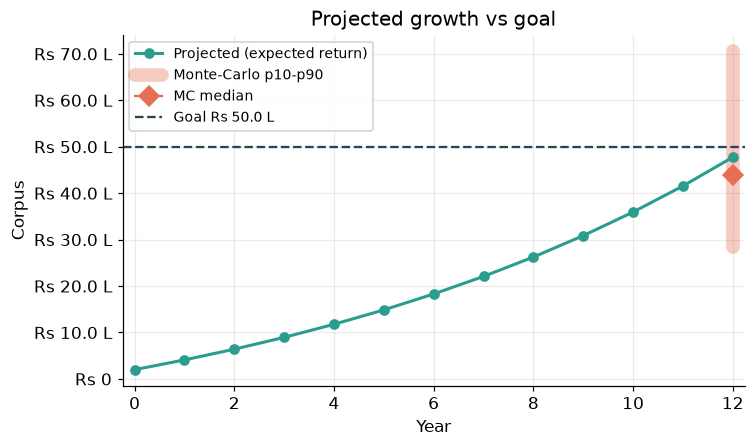

In [10]:
# Growth curve vs goal, with the Monte-Carlo p10–p90 range at the horizon.
traj = projection["trajectory"]
xs = [0] + [p["year"] for p in traj]
ys = [inputs["initial"]] + [p["value"] for p in traj]

fig, ax = plt.subplots()
ax.plot(xs, ys, marker="o", lw=2, color=EQUITY, label="Projected (expected return)", zorder=3)

yr = inputs["years"]
ax.plot([yr, yr], [mc["p10"], mc["p90"]], color=ACCENT, lw=9, alpha=0.35,
        solid_capstyle="round", label="Monte-Carlo p10-p90", zorder=2)
ax.plot([yr], [mc["median"]], marker="D", ms=9, color=ACCENT, label="MC median", zorder=4)
ax.axhline(inputs["goal"], ls="--", color=DEBT, lw=1.5,
           label=f"Goal {inr_compact(inputs['goal'])}")

ax.set_title("Projected growth vs goal")
ax.set_xlabel("Year"); ax.set_ylabel("Corpus")
ax.yaxis.set_major_formatter(plt.FuncFormatter(inr_compact))
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.margins(x=0.02)
plt.tight_layout(); plt.show()

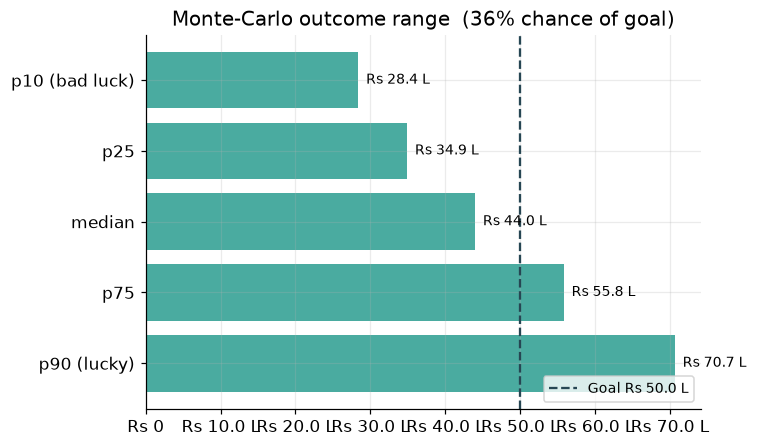

In [11]:
# The outcome distribution as percentile bars, against the goal line.
keys = ["p10", "p25", "median", "p75", "p90"]
labels = ["p10 (bad luck)", "p25", "median", "p75", "p90 (lucky)"]
vals = [mc[k] for k in keys]

fig, ax = plt.subplots()
bars = ax.barh(labels, vals, color=EQUITY, alpha=0.85)
ax.axvline(inputs["goal"], ls="--", color=DEBT, lw=1.5,
           label=f"Goal {inr_compact(inputs['goal'])}")
for b, v in zip(bars, vals):
    ax.text(v, b.get_y() + b.get_height() / 2, "  " + inr_compact(v), va="center", fontsize=9)
ax.set_title(f"Monte-Carlo outcome range  ({mc['probability_of_reaching_goal'] * 100:.0f}% chance of goal)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(inr_compact))
ax.invert_yaxis()
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

## 8. Feasibility — on track? and the three levers

[`check_feasibility`](../finplan/tools/feasibility.py) compares the projected corpus to the goal and, if
there's a gap, **inverts the future-value math** three ways to give independent levers: the required
monthly SIP (closed form), the required horizon (step-solve), and the required annual return
(**bisection** — robust because FV is monotonic in return).

In [12]:
from finplan.tools.feasibility import check_feasibility

feas = check_feasibility(inputs["initial"], inputs["monthly"], inputs["years"], er, inputs["goal"])
d = feas["difference"]
sign = "surplus" if d >= 0 else "shortfall"
print("On track       :", feas["on_track"])
print("Surplus/short  :", ("+" if d >= 0 else "-") + format_inr(abs(d)), f"({sign})")

lv = feas["to_reach_goal"]
rr = lv["required_annual_return"]
print("\nTo reach the goal, any ONE of:")
print("  Required SIP   :", format_inr(lv["required_monthly"]), "/month")
print("  Required years :", lv["required_years"])
print("  Required return:", f"{rr * 100:.2f}%/yr" if rr is not None else "n/a")

On track       : False
Surplus/short  : -₹2,26,937 (shortfall)

To reach the goal, any ONE of:
  Required SIP   : ₹15,826 /month
  Required years : 12.4
  Required return: 11.03%/yr


## 9. Inflation-adjusted target & after-tax corpus

Two honesty checks: the goal in **today's money** is worth more in future rupees
([`inflation_adjusted_goal`](../finplan/tools/feasibility.py), 6% default), and the corpus is subject to
**LTCG tax** ([`apply_ltcg_tax`](../finplan/tools/tax.py) — 12.5% over a ₹1.25 lakh exemption).

In [13]:
from finplan.tools.feasibility import inflation_adjusted_goal
from finplan.tools.tax import apply_ltcg_tax

infl_goal = inflation_adjusted_goal(inputs["goal"], inputs["years"])
tax = apply_ltcg_tax(projection["future_value"], projection["total_invested"])

print("Goal (today's money)   :", format_inr(inputs["goal"]))
print(f"Inflation-adjusted goal: {format_inr(infl_goal)}  (6% over {inputs['years']}y — the real target)")
print("Post-tax corpus        :", format_inr(tax["post_tax_corpus"]))
print("Estimated LTCG tax     :", format_inr(tax["estimated_tax"]))

Goal (today's money)   : ₹50,00,000
Inflation-adjusted goal: ₹1,00,60,982  (6% over 12y — the real target)
Post-tax corpus        : ₹44,87,055
Estimated LTCG tax     : ₹2,86,008


## 10. One call does all of it — `generate_plan()`

Everything above is chained in Python by the composite tool
[`generate_plan`](../finplan/planner.py). Chaining in code (not via the LLM) guarantees each step consumes
the **previous step's exact output** — no intermediate value is ever guessed by the model — and collapses a
plan from ~8 LLM round-trips to ~2. It returns a `summary` of pre-formatted strings the LLM quotes
verbatim. Because we used the same `_class_stats` above, the numbers match **exactly**.

In [14]:
import pandas as pd
from finplan.planner import generate_plan

plan = generate_plan(
    inputs["initial"], inputs["monthly"], inputs["years"],
    inputs["goal"], inputs["risk_tolerance"],
)

# Prove the composite pipeline reproduces the step-by-step numbers exactly.
assert abs(plan["expected_return"] - er) < 1e-9
assert plan["projection"]["future_value"] == projection["future_value"]
print("MATCH: generate_plan() reproduces the step-by-step numbers exactly.\n")

pd.DataFrame(list(plan["summary"].items()), columns=["metric", "value (pre-formatted for the LLM)"])

MATCH: generate_plan() reproduces the step-by-step numbers exactly.



,metric,value (pre-formatted for the LLM)
0,expected_return,10.37%
1,volatility,15.22%
2,projected_corpus,"₹47,73,063"
3,goal,"₹50,00,000"
4,median_outcome,"₹43,97,632"
5,range_p10_to_p90,"₹28,37,343 to ₹70,66,224"
6,probability_of_goal,35.8%
7,status,shortfall
8,gap,"₹2,26,937 short"
9,required_monthly_sip,"₹15,826"


## 11. (Optional) Ask the agent in natural language

Everything so far was **keyless and deterministic**. The LLM layer sits *on top*: it reads a messy
sentence, extracts the five inputs, calls `generate_plan` **once**, and explains the result — quoting the
`summary` strings verbatim. This cell runs only if a provider key is set; otherwise it prints how to enable
it and skips. Model selection is one line in `.env` (see [`finplan/config.py`](../finplan/config.py)).

In [15]:
import os

def has_llm_key() -> bool:
    # True only for a real key (rejects the `.env.example` "your-..." placeholder).
    keys = ("GOOGLE_API_KEY", "GROQ_API_KEY")
    return any((os.getenv(k) or "") and "your-" not in (os.getenv(k) or "") for k in keys)

if has_llm_key():
    from finplan.agent.planner_agent import build_agent, run_turn
    from finplan.config import describe_config

    print("Models:", describe_config())
    agent = build_agent()
    question = (
        "I have 2 lakh now, can add 15k a month for 12 years, "
        "my goal is 50 lakh at moderate risk. Make me a plan."
    )
    print("\nUSER:", question, "\n")
    try:
        print("AGENT:\n" + run_turn(agent, question, thread_id="notebook-demo"))
    except Exception as e:  # network/rate-limit/etc. — keep the notebook clean
        print("Agent call failed:", type(e).__name__, "-", e)
else:
    print("No LLM key detected - skipping the live agent section.")
    print("To enable it:")
    print("  1) copy .env.example to .env")
    print("  2) add GROQ_API_KEY (free at console.groq.com/keys)")
    print("  3) re-run this cell")

No LLM key detected - skipping the live agent section.


To enable it:
  1) copy .env.example to .env
  2) add GROQ_API_KEY (free at console.groq.com/keys)
  3) re-run this cell


---

### Recap

- **Steps 1–9** are pure functions in [`finplan/tools/`](../finplan/tools) — each with a known formula and
  unit tests, so every number is auditable and reproducible.
- **Step 10** chains them in Python ([`generate_plan`](../finplan/planner.py)) so intermediate values can't
  be hallucinated.
- **Step 11** is the LLM — it handles language and orchestration, and **quotes** the computed figures; it
  never does the math.

That split — *the model does language, verified systems do truth* — is the whole point.

*Educational project. Outputs are **not** financial advice.*